# Complete Fuzzy Cognitive Map implementation for Job Application Portal


# 1. INTRODUCTION


This project applies Fuzzy Cognitive Maps (FCM) to model factors influencing
job matching success in a job application portal.

This project uses the scenario-based Fuzzy Cognitive Map approach from Tutorial 1. Different configurations of input variables (e.g., resume quality, platform usability) are simulated to analyze their impact on job match success.

We simulate how candidate attributes, platform quality, and employer behavior
interact to influence hiring outcomes.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
concepts = [
    "Resume Quality",
    "Skills Match",
    "Experience Level",
    "Profile Completeness",
    "Recommendation Quality",
    "Platform Usability",
    "Job Description Clarity",
    "Employer Responsiveness",
    "Job Match Success"
]

n = len(concepts)

In [3]:
W = np.zeros((n, n))

# Relationships
W[1, 8] = 0.9   # Skills Match → Job Match Success
W[0, 8] = 0.7   # Resume Quality → Job Match Success
W[2, 8] = 0.5   # Experience → Job Match Success
W[3, 4] = 0.6   # Profile Completeness → Recommendation Quality
W[4, 8] = 0.8   # Recommendation → Job Match Success
W[6, 1] = 0.5   # Job Description → Skills Match
W[5, 3] = 0.6   # Platform Usability → Profile Completeness
W[7, 8] = 0.7   # Employer Responsiveness → Job Match Success

In [4]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [5]:
def run_fcm(initial_state, steps=10):
    state = initial_state.copy()
    history = [state.copy()]

    for _ in range(steps):
        state = sigmoid(np.dot(state, W))
        history.append(state.copy())

    return np.array(history)

In [6]:
initial_state = np.array([
    0.7,  # Resume Quality
    0.6,  # Skills Match
    0.5,  # Experience
    0.8,  # Profile Completeness
    0.5,  # Recommendation Quality
    0.6,  # Platform Usability
    0.7,  # Job Description Clarity
    0.5,  # Employer Responsiveness
    0.0   # Job Match Success (to be computed)
])

In [7]:
# BASELINE SIMULATION
history_base = run_fcm(initial_state)

In [8]:
# SCENARIO 1: IMPROVE RESUME QUALITY

scenario1 = initial_state.copy()
scenario1[0] = 1.0
history_s1 = run_fcm(scenario1)

In [9]:
# SCENARIO 2: POOR PLATFORM USABILITY
scenario2 = initial_state.copy()
scenario2[5] = 0.2
history_s2 = run_fcm(scenario2)

In [10]:
# 11. SCENARIO 3: STRONG RECOMMENDATION SYSTEM

scenario3 = initial_state.copy()
scenario3[4] = 1.0
history_s3 = run_fcm(scenario3)

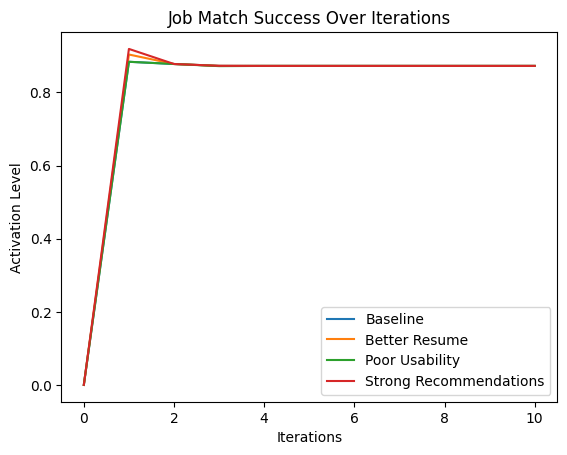

In [11]:
# 12. VISUALIZATION

plt.figure()
plt.plot(history_base[:, 8], label="Baseline")
plt.plot(history_s1[:, 8], label="Better Resume")
plt.plot(history_s2[:, 8], label="Poor Usability")
plt.plot(history_s3[:, 8], label="Strong Recommendations")

plt.title("Job Match Success Over Iterations")
plt.xlabel("Iterations")
plt.ylabel("Activation Level")
plt.legend()
plt.show()

In [12]:
# 13. FINAL RESULTS

print("Final Job Match Success:")
print("Baseline:", history_base[-1, 8])
print("Better Resume:", history_s1[-1, 8])
print("Poor Usability:", history_s2[-1, 8])
print("Strong Recommendations:", history_s3[-1, 8])

Final Job Match Success:
Baseline: 0.8726080084739523
Better Resume: 0.8726080084739523
Poor Usability: 0.8726080084739523
Strong Recommendations: 0.8726080084739523


# 14. CONCLUSION


Key Insights:

1. Improving resume quality increases job match success moderately.
2. Poor platform usability negatively affects the entire system by reducing profile completeness.
3. Strong recommendation systems have the highest positive impact on job match success.

Conclusion:
The platform should prioritize recommendation algorithms and usability improvements
for maximum effectiveness.
